<a href="https://colab.research.google.com/github/daiana-o/DS-Milestone-1-Project/blob/main/Daiana_Project1_Milestone2_Data_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Milestone 2

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df = pd.read_csv("netflix_user_behavior_dataset.csv")
df.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


In [62]:
df.isna().sum()

,0
user_id,0
age,0
gender,0
country,0
account_age_months,0
subscription_type,0
monthly_fee,0
payment_method,0
primary_device,0
devices_used,0


In [63]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'account_age_months',
       'subscription_type', 'monthly_fee', 'payment_method', 'primary_device',
       'devices_used', 'favorite_genre', 'avg_watch_time_minutes',
       'watch_sessions_per_week', 'binge_watch_sessions', 'completion_rate',
       'rating_given', 'content_interactions', 'recommendation_click_rate',
       'days_since_last_login', 'churned'],
      dtype='object')

Step 8: model 1
+ a. Choose a column in your dataset to predict using some or all of the other columns.. This can either be a quantitative column to perform regression on, or a qualitative column to perform classification on.
+ b. Prepare your data for machine learning:  split your data into training and testing data, and if necessary, create dummy variables or scale columns.
+ c. Fit a model that we covered in class to your training data.   The models covered in class are linear regression, polynomial regression, decision trees, k-nearest neighbors, and logistic regression.
+ d. Evaluate the fit of your model using your testing and training data.  You should use the appropriate methods for your model.
+ e. Repeat steps (c) and (d) with at least two different parameters for your model.  For linear regression, you should use different subsets of the independent variables (for example, by dropping independent variables with high p-values).
+ f. Post your code to GitHub.
+ g. Describe what prediction model and parameters you tried on your webpage, as well as how you evaluated the model/parameter combinations and the results of the evaluation (ex. pros and cons of this model/parameter combo).  Conclude with recommending which parameter to use with this model to get the best predictions for your data.

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

In [65]:
df = df.dropna()
df = df.drop(columns=["user_id"])
df.head()

,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


In [66]:
model = pd.get_dummies(df, drop_first=True)

x = model.drop(columns = "churned_Yes", axis=1)
y = model["churned_Yes"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [67]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

In [68]:
model.columns

Index(['age', 'account_age_months', 'monthly_fee', 'devices_used',
       'avg_watch_time_minutes', 'watch_sessions_per_week',
       'binge_watch_sessions', 'completion_rate', 'rating_given',
       'content_interactions', 'recommendation_click_rate',
       'days_since_last_login', 'gender_Male', 'gender_Other',
       'country_Brazil', 'country_Canada', 'country_France', 'country_Germany',
       'country_India', 'country_Japan', 'country_Spain', 'country_UK',
       'country_USA', 'subscription_type_Premium',
       'subscription_type_Standard', 'payment_method_Debit Card',
       'payment_method_PayPal', 'payment_method_UPI', 'primary_device_Mobile',
       'primary_device_Smart TV', 'primary_device_Tablet',
       'favorite_genre_Comedy', 'favorite_genre_Documentary',
       'favorite_genre_Drama', 'favorite_genre_Horror',
       'favorite_genre_Romance', 'favorite_genre_Sci-Fi',
       'favorite_genre_Thriller', 'churned_Yes'],
      dtype='object')

In [69]:
df.shape

(50000, 19)

In [70]:
model.shape

(50000, 39)

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score


model_1 = LogisticRegression(max_iter=50000, C=1, class_weight='balanced')
model_1.fit(x_train_s, y_train)

LogisticRegression(C=1, class_weight='balanced', max_iter=50000)

In [72]:
y_pred1 = model_1.predict(x_test_s)
print("Accuracy:  ", accuracy_score(y_test, y_pred1))
print("Recall:    ", recall_score(y_test, y_pred1))
print("Precision: ", precision_score(y_test, y_pred1))
print("F1:        ",f1_score(y_test, y_pred1))

Accuracy:   0.5009
Recall:     0.47236438075742065
Precision:  0.18902314151136596
F1:         0.2700014626298084


In [73]:
model_2 = LogisticRegression(max_iter=50000, C=0.01, class_weight='balanced')
model_2.fit(x_train_s, y_train)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=50000)

In [74]:
y_pred2 = model_2.predict(x_test_s)
print("Accuracy:  ", accuracy_score(y_test, y_pred2))
print("Recall:    ",recall_score(y_test, y_pred2))
print("Precision: ", precision_score(y_test, y_pred2))
print("F1:        ", f1_score(y_test, y_pred2))

Accuracy:   0.4996
Recall:     0.47389969293756395
Precision:  0.18890248878008975
F1:         0.2701283547257876


In [75]:
model_3 = LogisticRegression(max_iter=50000, C=10, class_weight='balanced')
model_3.fit(x_train_s, y_train)

LogisticRegression(C=10, class_weight='balanced', max_iter=50000)

In [76]:
y_pred3 = model_3.predict(x_test_s)
print("Accuracy:  ", accuracy_score(y_test, y_pred3))
print("Recall:    ",recall_score(y_test, y_pred3))
print("Precision: ", precision_score(y_test, y_pred3))
print("F1:        ", f1_score(y_test, y_pred3))

Accuracy:   0.5008
Recall:     0.47236438075742065
Precision:  0.18898443898443898
F1:         0.26996197718631176


In [77]:
# Prediction model description: Logic Regression was used to predict user churn since this is a classification  problem. Through all three model regression C=1, C=0.01, and C=10 when adjusted, there accuracy, recall, precision, and F1 remained similar across all models.
# pros: "class_weight" for handling class imbalance, scaler used for more coherent/accurate data, Across all different C parameters stable outputs.
# cons: low F1 meaning poor balance between precision and recall, low precision as well. Accuracy around 50% which is not great.
# Parameter recommendation for model:

Step 9: model 2
In this step, you will predict the same variable as in Step 8 but using a different machine learning model:
+ a). Fit a different model that the one used in Step 8 to your training data.  You must use a model covered in class (linear regression, polynomial regression, decision trees, k-nearest neighbors, logistic regression).
+ a). Evaluate the fit of your 2nd model using your testing and training data.  You should use the appropriate methods for your model.
+ b). Repeat steps (c) and (d) with at least two different parameters for your 2nd model.  For linear regression, you can use different subsets of the independent variables (for example, by dropping independent variables with high p-values).
+ c. Post your code to GitHub.
+ d. Describe what prediction model and parameters you tried on your webpage, as well as how you evaluated the model/parameter combinations and the results of the evaluation (ex. pros and cons of this model/parameter combo).  Conclude with recommending which parameter to use with this 2nd model to get the best predictions for your data.
+ e. Compare the how well Model 1 (Step 8) and Model 2 (Step 9) preformed on your data, and make a final recommendation of which model to use to make the predictions.

In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [79]:
model_one = DecisionTreeClassifier(max_depth=3, random_state=42)
model_one.fit(x_train_s, y_train)

ypred_one = model_one.predict(x_test_s)

print("Accuracy:  ", accuracy_score(y_test, ypred_one))
print("Recall:    ",recall_score(y_test, ypred_one))
print("Precision: ", precision_score(y_test, ypred_one))
print("F1:        ", f1_score(y_test, ypred_one))

Accuracy:   0.8046
Recall:     0.0
Precision:  0.0
F1:         0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


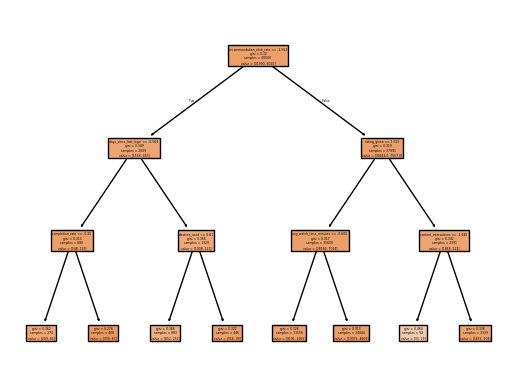

In [80]:
plt.figure()

plot_tree(model_one, feature_names=x.columns, filled=True)
plt.show()

In [81]:
model_two= DecisionTreeClassifier(max_depth=5, random_state=42)
model_two.fit(x_train_s, y_train)

ypred_two = model_two.predict(x_test_s)

print("Accuracy:  ", accuracy_score(y_test, ypred_two))
print("Recall:    ",recall_score(y_test, ypred_two))
print("Precision: ", precision_score(y_test, ypred_two))
print("F1:        ", f1_score(y_test, ypred_two))

Accuracy:   0.8036
Recall:     0.0015353121801432957
Precision:  0.1875
F1:         0.003045685279187817


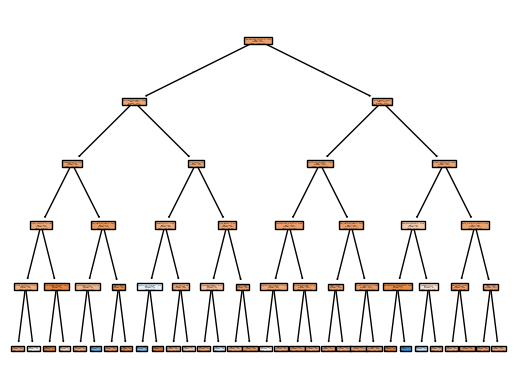

In [82]:
plt.figure()

plot_tree(model_two, feature_names=x.columns, filled=True)
plt.show()

In [83]:
model_three= DecisionTreeClassifier(max_depth=10, random_state=42)
model_three.fit(x_train_s, y_train)

ypred_three = model_three.predict(x_test_s)

print("Accuracy:  ", accuracy_score(y_test, ypred_three))
print("Recall:    ",recall_score(y_test, ypred_three))
print("Precision: ", precision_score(y_test, ypred_three))
print("F1:        ", f1_score(y_test, ypred_three))

Accuracy:   0.7936
Recall:     0.02047082906857728
Precision:  0.21052631578947367
F1:         0.03731343283582089


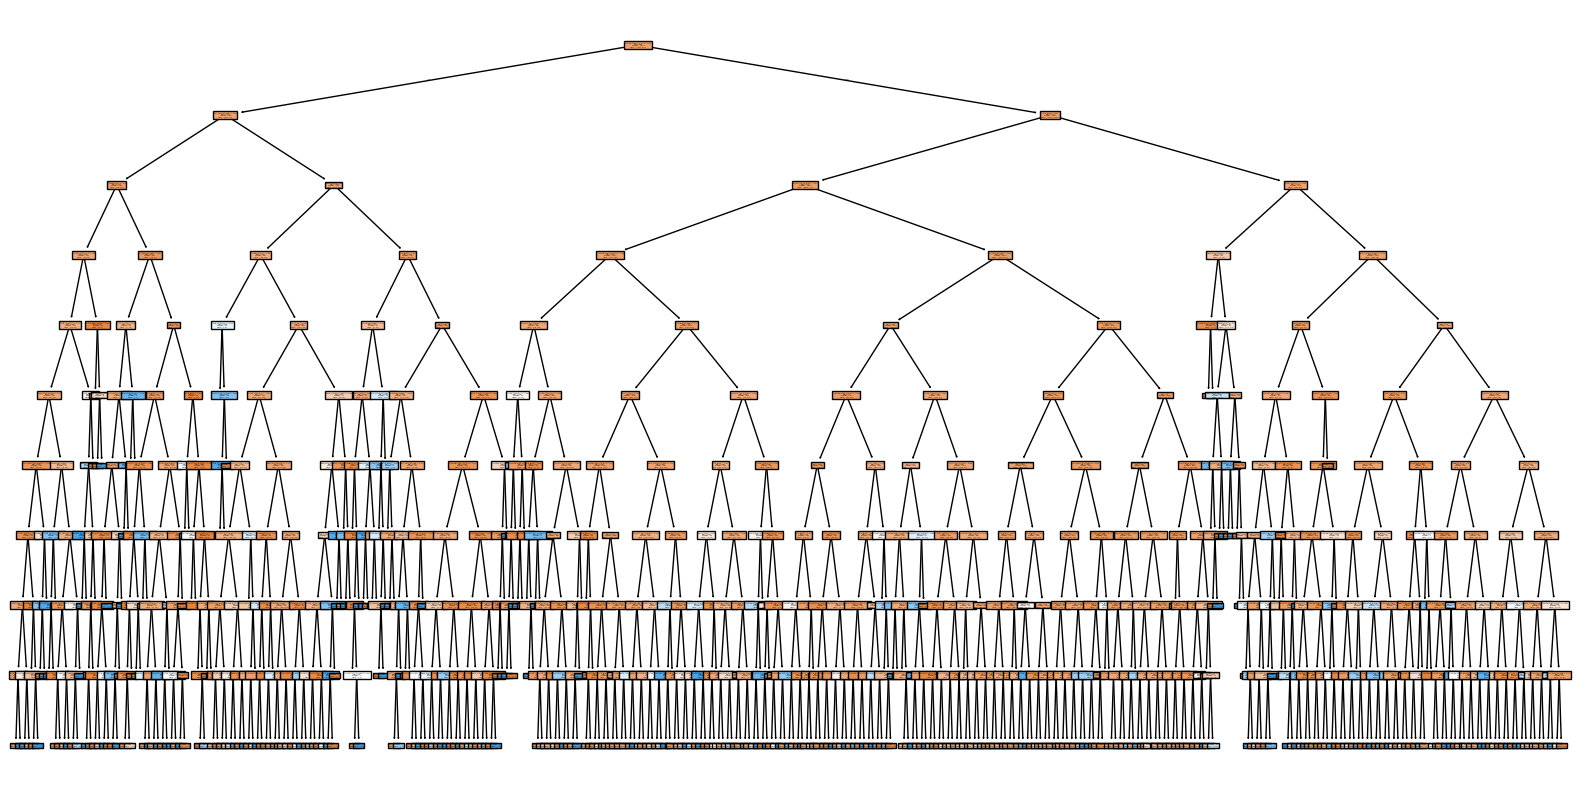

In [57]:
plt.figure()

plot_tree(model_three, feature_names=x.columns, filled=True)
plt.show()

In [58]:
# Decision tree was used as the predicition model with the paramerters max_depth of 3,5, and 10 tested.
# Pros:
# Cons:
# Recommended parameter for best predicition:

In [59]:
# Compare Model 1 (Step 8) and Model 2(Step 9):
# - Model 1
# - Model 1
# - Model 2 does not need scaling nor class_weight for handling the data
# - Model 2 is more easier to visually see the data
# Recommendation on which model should be used to make a better predicition: